# University Rankings Analysis — Milestone 1 & 2



## Step 1 — Import libraries
Standard data-analysis stack: `pandas`/`numpy` for data handling, `matplotlib`/`seaborn` for the required visualizations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully")

Libraries imported successfully


## Step 2 — Load the merged dataset


In [2]:
university_data = pd.read_csv("university_cleaned_merged.csv")

print("Dataset Shape:", university_data.shape)
university_data.head()

Dataset Shape: (1501, 41)


                              Institution Name Country/Territory    Region  \
0  Massachusetts Institute of Technology (MIT)     United States  Americas   
1                      Imperial College London    United Kingdom    Europe   
2                          Stanford University     United States  Americas   
3                         University of Oxford    United Kingdom    Europe   
4                           Harvard University     United States  Americas   

  University Size Focus Research                  Status 2026 Rank  \
0               M    CO       VH  Private not for Profit         1   
1               L    FO       VH                  Public         2   
2               L    FC       VH  Private not for Profit         3   
3               L    FC       VH                  Public         4   
4               L    FC       VH  Private not for Profit         5   

   2026 Rank Clean shanghai_world_rank  shanghai_world_rank_clean  \
0              1.0                   3   

## Step 3 — Understand the dataset


In [3]:
university_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1501 entries, 0 to 1500
Data columns (total 41 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Institution Name           1501 non-null   str    
 1   Country/Territory          1501 non-null   str    
 2   Region                     1501 non-null   str    
 3   University Size            1500 non-null   str    
 4   Focus                      1501 non-null   str    
 5   Research                   1500 non-null   str    
 6   Status                     1454 non-null   str    
 7   2026 Rank                  1501 non-null   str    
 8   2026 Rank Clean            1501 non-null   float64
 9   shanghai_world_rank        354 non-null    str    
 10  shanghai_world_rank_clean  1501 non-null   float64
 11  shanghai_national_rank     354 non-null    str    
 12  shanghai_data_year         1501 non-null   float64
 13  Overall SCORE              1501 non-null   str    
 14  sha

## Step 4 — Check column names
Worth listing explicitly, since later steps reference exact column names and mixed-case/spaced names (e.g. `"2026 Rank"`, `"AR SCORE"`) are easy to mistype.

In [4]:
print(university_data.columns.tolist())

['Institution Name', 'Country/Territory', 'Region', 'University Size', 'Focus', 'Research', 'Status', '2026 Rank', '2026 Rank Clean', 'shanghai_world_rank', 'shanghai_world_rank_clean', 'shanghai_national_rank', 'shanghai_data_year', 'Overall SCORE', 'shanghai_total_score', 'AR SCORE', 'AR RANK', 'ER SCORE', 'ER RANK', 'FSR SCORE', 'FSR RANK', 'CPF SCORE', 'CPF RANK', 'IFR SCORE', 'IFR RANK', 'ISR SCORE', 'ISR RANK', 'ISD SCORE', 'ISD RANK', 'IRN SCORE', 'IRN RANK', 'EO SCORE', 'EO RANK', 'SUS SCORE', 'SUS RANK', 'shanghai_alumni_score', 'shanghai_award_score', 'shanghai_hici_score', 'shanghai_ns_score', 'shanghai_pub_score', 'shanghai_pcp_score']


## Step 5 — Standardize column names


In [5]:
university_data.columns = (
    university_data.columns
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)

print(university_data.columns.tolist())

['institution_name', 'country_territory', 'region', 'university_size', 'focus', 'research', 'status', '2026_rank', '2026_rank_clean', 'shanghai_world_rank', 'shanghai_world_rank_clean', 'shanghai_national_rank', 'shanghai_data_year', 'overall_score', 'shanghai_total_score', 'ar_score', 'ar_rank', 'er_score', 'er_rank', 'fsr_score', 'fsr_rank', 'cpf_score', 'cpf_rank', 'ifr_score', 'ifr_rank', 'isr_score', 'isr_rank', 'isd_score', 'isd_rank', 'irn_score', 'irn_rank', 'eo_score', 'eo_rank', 'sus_score', 'sus_rank', 'shanghai_alumni_score', 'shanghai_award_score', 'shanghai_hici_score', 'shanghai_ns_score', 'shanghai_pub_score', 'shanghai_pcp_score']


## Step 6 — Define the key columns we'll work with


In [6]:
name_col = "institution_name"
country_col = "country_territory"

qs_rank_raw = "2026_rank"          # QS World Ranking 2026 (raw, may contain ranges/"+")
sh_rank_raw = "shanghai_world_rank"  # Shanghai/ARWU World Ranking (raw, may contain ranges)

print("Using name column:", name_col)
print("Using country column:", country_col)
print("Using QS raw rank:", qs_rank_raw)
print("Using Shanghai raw rank:", sh_rank_raw)

Using name column: institution_name
Using country column: country_territory
Using QS raw rank: 2026_rank
Using Shanghai raw rank: shanghai_world_rank


## Step 7 — Clean the institution name column


In [7]:
university_data[name_col] = (
    university_data[name_col]
    .astype("string")
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

print("University names cleaned successfully.")

University names cleaned successfully.


## Step 8 — Check data quality *before* cleaning


In [8]:
print("Records before cleaning:", len(university_data))
print("Fully duplicate rows:", university_data.duplicated().sum())
print("Duplicate institution names:", university_data[name_col].duplicated().sum())

print("\nMissing values in key columns:")
university_data[[name_col, country_col, qs_rank_raw, sh_rank_raw]].isnull().sum()

Records before cleaning: 1501
Fully duplicate rows: 0
Duplicate institution names: 0

Missing values in key columns:


institution_name          0
country_territory         0
2026_rank                 0
shanghai_world_rank    1147
dtype: int64

## Step 9 — Remove duplicate records


In [9]:
records_before = len(university_data)

university_data = university_data.drop_duplicates().copy()

print("Records before:", records_before, "| Records after duplicate removal:", len(university_data))

Records before: 1501 | Records after duplicate removal: 1501


## Step 10 — Convert ranking values into numbers


In [10]:
def convert_rank(value):

    if pd.isna(value):
        return np.nan

    rank_text = str(value).strip()

    if rank_text.lower() in ("reporter", "n/a", "na", "-", ""):
        return np.nan

    rank_text = (
        rank_text
        .replace("\u2013", "-")
        .replace("\u2014", "-")
    )

    # Handle values such as 1401+
    if "+" in rank_text:
        digits = "".join(ch for ch in rank_text if ch.isdigit())
        return float(digits) if digits else np.nan

    # Handle ranking ranges such as 101-150
    if "-" in rank_text:
        parts = [p for p in rank_text.split("-") if p.strip().isdigit()]
        if len(parts) == 2:
            lower_rank, upper_rank = float(parts[0]), float(parts[1])
            return (lower_rank + upper_rank) / 2

    # Handle normal numerical ranks
    try:
        return float(rank_text)
    except ValueError:
        return np.nan

print("convert_rank() defined.")

convert_rank() defined.


## Step 11 — Apply the conversion and create clean ranking columns


In [11]:
university_data["qs_rank_band"] = university_data[qs_rank_raw].astype(str)
university_data["shanghai_rank_band"] = university_data[sh_rank_raw].astype(str)

university_data["qs_rank_clean"] = university_data[qs_rank_raw].apply(convert_rank)
university_data["shanghai_rank_clean"] = university_data[sh_rank_raw].apply(convert_rank)

print(university_data["qs_rank_clean"].dtype, university_data["shanghai_rank_clean"].dtype)

university_data[[qs_rank_raw, "qs_rank_clean", sh_rank_raw, "shanghai_rank_clean"]].head(10)

float64 float64


  2026_rank  qs_rank_clean shanghai_world_rank  shanghai_rank_clean
0         1            1.0                   3                  3.0
1         2            2.0                 NaN                  NaN
2         3            3.0                   2                  2.0
3         4            4.0                  10                 10.0
4         5            5.0                   1                  1.0
5         6            6.0                   5                  5.0
6         7            7.0                 NaN                  NaN
7         8            8.0             101-150                125.5
8         9            9.0                 NaN                  NaN
9        10           10.0                   7                  7.0

## Step 12 — Missing-value check: why we do **not** blanket-fill Shanghai rank


In [12]:
core_cols = [name_col, country_col, "region", "university_size", "focus", "research",
             "status", qs_rank_raw, "qs_rank_clean"]

core_missing_pct = (university_data[core_cols].isnull().mean() * 100).round(2)
print("Missing % — core descriptive + QS ranking columns:")
print(core_missing_pct)

sh_missing_pct = university_data["shanghai_rank_clean"].isnull().mean() * 100
sh_covered = (~university_data["shanghai_rank_clean"].isnull()).sum()
print(f"\nMissing % — shanghai_rank_clean: {sh_missing_pct:.2f}%  "
      f"({sh_covered} of {len(university_data)} universities are ARWU-ranked)")

Missing % — core descriptive + QS ranking columns:
institution_name     0.00
country_territory    0.00
region               0.00
university_size      0.07
focus                0.00
research             0.07
status               3.13
2026_rank            0.00
qs_rank_clean        0.00
dtype: float64

Missing % — shanghai_rank_clean: 76.42%  (354 of 1501 universities are ARWU-ranked)


## Step 13 — Create ranking bands (categories)


In [13]:
def create_rank_category(rank):
    if pd.isna(rank):
        return "Unranked"
    elif rank <= 10:
        return "Top 10"
    elif rank <= 50:
        return "11-50"
    elif rank <= 100:
        return "51-100"
    elif rank <= 500:
        return "101-500"
    else:
        return "Above 500"

university_data["qs_rank_category"] = university_data["qs_rank_clean"].apply(create_rank_category)
university_data["shanghai_rank_category"] = university_data["shanghai_rank_clean"].apply(create_rank_category)

print("QS Ranking Categories:")
print(university_data["qs_rank_category"].value_counts())

print("\nShanghai Ranking Categories:")
print(university_data["shanghai_rank_category"].value_counts())

QS Ranking Categories:
qs_rank_category
Above 500    999
101-500      402
51-100        50
11-50         40
Top 10        10
Name: count, dtype: int64

Shanghai Ranking Categories:
shanghai_rank_category
Unranked    1147
101-500      286
51-100        34
11-50         24
Top 10        10
Name: count, dtype: int64


## Step 14 — Rank difference & QS vs. Shanghai comparison


In [14]:
university_data["rank_difference"] = (
    university_data["shanghai_rank_clean"] - university_data["qs_rank_clean"]
)
university_data["absolute_rank_difference"] = university_data["rank_difference"].abs()

def compare_rankings(row):
    qs_value = row["qs_rank_clean"]
    sh_value = row["shanghai_rank_clean"]

    if pd.isna(qs_value) or pd.isna(sh_value):
        return "Not Comparable"
    elif qs_value < sh_value:
        return "QS Higher"
    elif qs_value > sh_value:
        return "Shanghai Higher"
    else:
        return "Same Rank"

university_data["ranking_comparison"] = university_data.apply(compare_rankings, axis=1)

print(university_data["ranking_comparison"].value_counts())

ranking_comparison
Not Comparable     1147
Shanghai Higher     227
QS Higher           126
Same Rank             1
Name: count, dtype: int64


## Step 15 — Milestone 1 final validation


In [15]:
print("Final Number of Records:", len(university_data))
print("Final Number of Columns:", len(university_data.columns))
print("Duplicate Records:", university_data.duplicated().sum())
print("Core columns missing % (max):", core_missing_pct.max(), "%  -> target <2% met")
print("Countries covered:", university_data[country_col].nunique())

Final Number of Records: 1501
Final Number of Columns: 50
Duplicate Records: 0
Core columns missing % (max): 3.13 %  -> target <2% met
Countries covered: 106


## Step 16 — Save the Milestone 1 deliverable


In [16]:
university_data.to_csv("university_cleaned.csv", index=False)
print("Saved: university_cleaned.csv")
print("Shape:", university_data.shape)

Saved: university_cleaned.csv
Shape: (1501, 50)


## Step 16b — Fix a hidden data-type issue: `overall_score`


In [17]:
university_data["overall_score"] = pd.to_numeric(
    university_data["overall_score"], errors="coerce"
)

print("overall_score dtype now:", university_data["overall_score"].dtype)
print("Missing after conversion:", university_data["overall_score"].isnull().sum(),
      "out of", len(university_data))

overall_score dtype now: float64
Missing after conversion: 798 out of 1501


---
# Milestone 2 — KPI Engineering & Analysis



In [18]:
university_data["global_ranking_score"] = university_data["overall_score"]
university_data["academic_reputation_score"] = university_data["ar_score"]
university_data["faculty_student_ratio_score"] = university_data["fsr_score"]
university_data["international_student_score"] = university_data["isr_score"]
university_data["research_impact_score"] = university_data["cpf_score"]

university_data["research_productivity_index"] = university_data[
    ["shanghai_pub_score", "shanghai_hici_score", "shanghai_ns_score"]
].mean(axis=1)

kpi_cols = ["global_ranking_score", "academic_reputation_score", "faculty_student_ratio_score",
            "international_student_score", "research_impact_score", "research_productivity_index"]

print("KPI columns created. Missing values in each:")
print(university_data[kpi_cols].isnull().sum())

university_data[[name_col] + kpi_cols].head(10)

KPI columns created. Missing values in each:
global_ranking_score           798
academic_reputation_score        0
faculty_student_ratio_score      0
international_student_score      0
research_impact_score            0
research_productivity_index      0
dtype: int64


                                    institution_name  global_ranking_score  \
0        Massachusetts Institute of Technology (MIT)                 100.0   
1                            Imperial College London                  99.4   
2                                Stanford University                  98.9   
3                               University of Oxford                  97.9   
4                                 Harvard University                  97.7   
5                            University of Cambridge                  97.2   
6  ETH Zurich (Swiss Federal Institute of Technol...                  96.7   
7             National University of Singapore (NUS)                  95.9   
8                    UCL (University College London)                  95.8   
9       California Institute of Technology (Caltech)                  94.3   

   academic_reputation_score  faculty_student_ratio_score  \
0                      100.0                        100.0   
1                  

## Step 17 — Overall KPI summary table
The headline numbers for the dashboard's top KPI cards (mirrors the "Total Universities / Avg Score / etc." cards in the sample layout).

In [19]:
kpi_values = {
    "Total Universities": university_data[name_col].nunique(),
    "Countries Covered": university_data[country_col].nunique(),
    "Avg Global Ranking Score": round(university_data["global_ranking_score"].mean(), 2),
    "Avg Academic Reputation Score": round(university_data["academic_reputation_score"].mean(), 2),
    "Avg Research Impact Score": round(university_data["research_impact_score"].mean(), 2),
    "Avg Research Productivity Index": round(university_data["research_productivity_index"].mean(), 2),
    "Universities Ranked by Both Systems": int((university_data["ranking_comparison"] != "Not Comparable").sum()),
    "Avg Absolute Rank Difference (overlap only)": round(university_data["absolute_rank_difference"].mean(), 2),
}

kpi_table = pd.DataFrame(list(kpi_values.items()), columns=["KPI", "Value"])
kpi_table

                                           KPI    Value
0                           Total Universities  1501.00
1                            Countries Covered   106.00
2                     Avg Global Ranking Score    46.76
3                Avg Academic Reputation Score    25.79
4                    Avg Research Impact Score    30.43
5              Avg Research Productivity Index    20.08
6          Universities Ranked by Both Systems   354.00
7  Avg Absolute Rank Difference (overlap only)   195.29

## Step 18 — Top 10 universities by QS and by Shanghai/ARWU

In [20]:
top_qs = university_data.sort_values("qs_rank_clean")[[name_col, country_col, "qs_rank_clean"]].head(10)
print("Top 10 — QS World Ranking 2026")
display_top_qs = top_qs.reset_index(drop=True)
print(display_top_qs)

Top 10 — QS World Ranking 2026
                                    institution_name country_territory  \
0        Massachusetts Institute of Technology (MIT)     United States   
1                            Imperial College London    United Kingdom   
2                                Stanford University     United States   
3                               University of Oxford    United Kingdom   
4                                 Harvard University     United States   
5                            University of Cambridge    United Kingdom   
6  ETH Zurich (Swiss Federal Institute of Technol...       Switzerland   
7             National University of Singapore (NUS)         Singapore   
8                    UCL (University College London)    United Kingdom   
9       California Institute of Technology (Caltech)     United States   

   qs_rank_clean  
0            1.0  
1            2.0  
2            3.0  
3            4.0  
4            5.0  
5            6.0  
6            7.0  
7 

In [21]:
top_shanghai = (
    university_data.dropna(subset=["shanghai_rank_clean"])
    .sort_values("shanghai_rank_clean")[[name_col, country_col, "shanghai_rank_clean"]]
    .head(10)
    .reset_index(drop=True)
)
print("Top 10 — Shanghai Ranking (ARWU)")
print(top_shanghai)

Top 10 — Shanghai Ranking (ARWU)
                               institution_name country_territory  \
0                            Harvard University     United States   
1                           Stanford University     United States   
2   Massachusetts Institute of Technology (MIT)     United States   
3      University of California, Berkeley (UCB)     United States   
4                       University of Cambridge    United Kingdom   
5                          Princeton University     United States   
6  California Institute of Technology (Caltech)     United States   
7                           Columbia University     United States   
8                         University of Chicago     United States   
9                          University of Oxford    United Kingdom   

   shanghai_rank_clean  
0                  1.0  
1                  2.0  
2                  3.0  
3                  4.0  
4                  5.0  
5                  6.0  
6                  7.0  
7      

## Step 19 — Universities with the largest QS vs. Shanghai rank gap
Only meaningful for universities ranked by both systems, so `Not Comparable` rows are excluded first.

In [22]:
largest_gaps = (
    university_data[university_data["ranking_comparison"] != "Not Comparable"]
    .sort_values("absolute_rank_difference", ascending=False)
    [[name_col, country_col, "qs_rank_clean", "shanghai_rank_clean", "rank_difference", "absolute_rank_difference"]]
    .head(10)
    .reset_index(drop=True)
)
largest_gaps

                   institution_name country_territory  qs_rank_clean  \
0              Yamaguchi University             Japan         1401.0   
1         Portland State University     United States         1300.5   
2                  Gunma University             Japan         1300.5   
3              Kagoshima University             Japan         1300.5   
4       New Mexico State University     United States         1300.5   
5           George Mason University     United States          975.5   
6  Virginia Commonwealth University     United States          925.5   
7             University of Vermont     United States         1100.5   
8             University of Wyoming     United States         1100.5   
9        San Diego State University     United States         1100.5   

   shanghai_rank_clean  rank_difference  absolute_rank_difference  
0                450.5           -950.5                     950.5  
1                450.5           -850.0                     850.0  
2  

## Step 20 — Visualization 1: QS Rank vs. Shanghai Rank (scatter)
Only plotted for universities ranked by both — a tight diagonal cluster would mean the two systems broadly agree.

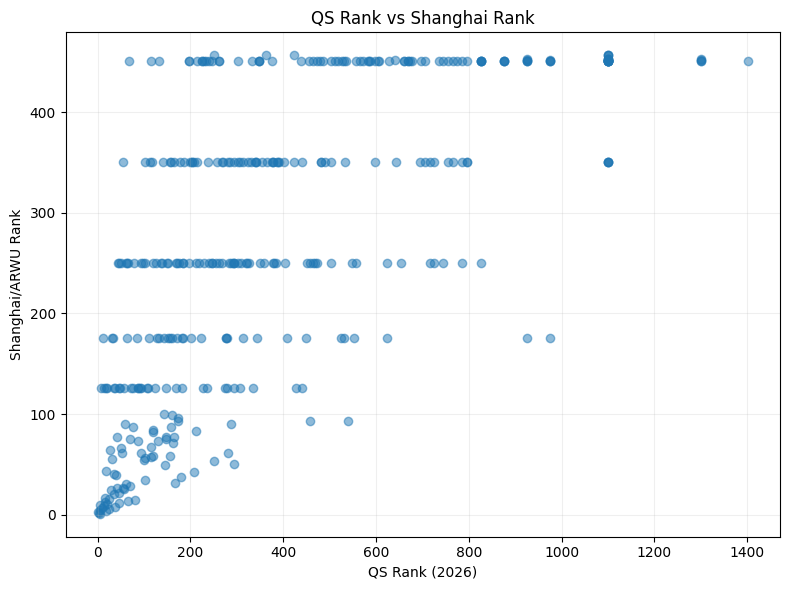

In [23]:
plot_data = university_data.dropna(subset=["qs_rank_clean", "shanghai_rank_clean"])

plt.figure(figsize=(8, 6))
plt.scatter(plot_data["qs_rank_clean"], plot_data["shanghai_rank_clean"], alpha=0.5)
plt.xlabel("QS Rank (2026)")
plt.ylabel("Shanghai/ARWU Rank")
plt.title("QS Rank vs Shanghai Rank")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("chart_1_qs_vs_shanghai_scatter.png", dpi=120)
plt.show()

## Step 21 — Visualization 2: Rank-difference distribution (histogram)

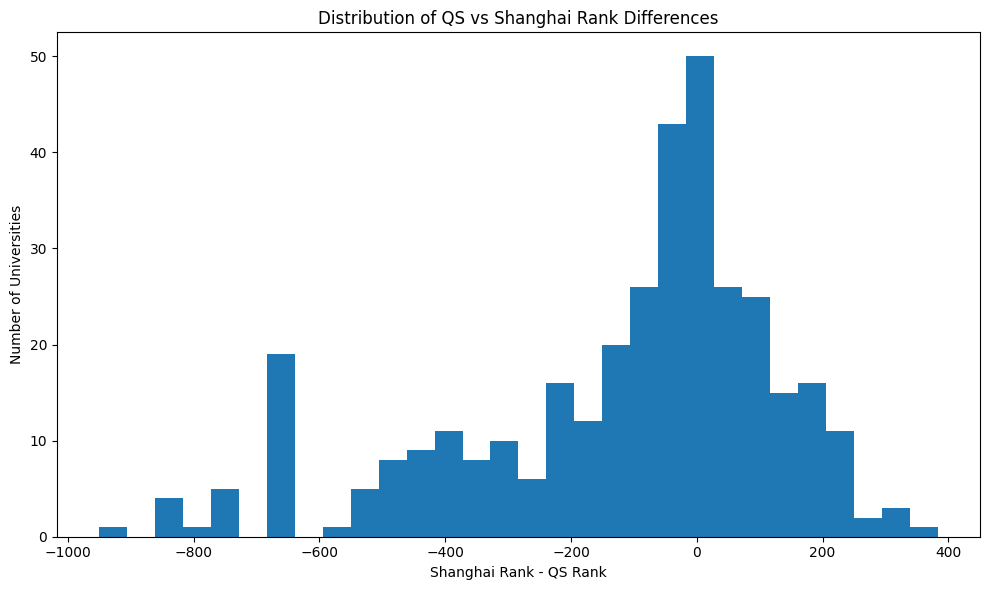

In [24]:
plt.figure(figsize=(10, 6))
plt.hist(university_data["rank_difference"].dropna(), bins=30)
plt.xlabel("Shanghai Rank - QS Rank")
plt.ylabel("Number of Universities")
plt.title("Distribution of QS vs Shanghai Rank Differences")
plt.tight_layout()
plt.savefig("chart_2_rank_difference_hist.png", dpi=120)
plt.show()

## Step 22 — Visualization 3 & 4: Ranking category bar charts

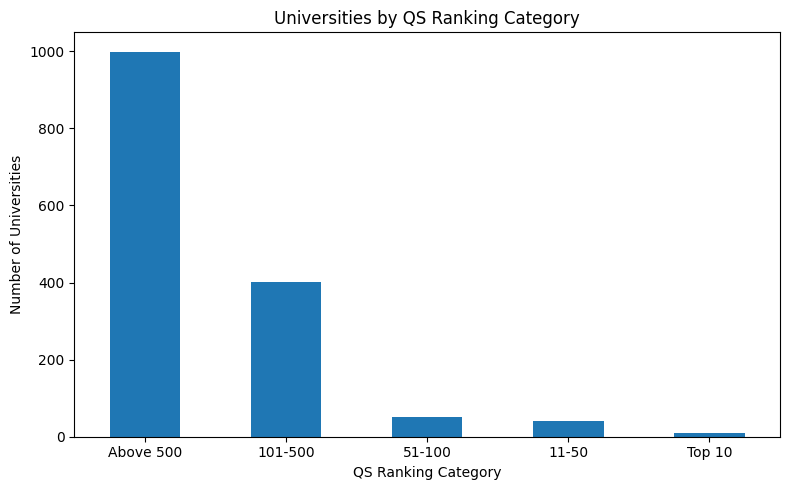

In [25]:
qs_category_counts = university_data["qs_rank_category"].value_counts()

plt.figure(figsize=(8, 5))
qs_category_counts.plot(kind="bar")
plt.xlabel("QS Ranking Category")
plt.ylabel("Number of Universities")
plt.title("Universities by QS Ranking Category")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("chart_3_qs_category_bar.png", dpi=120)
plt.show()

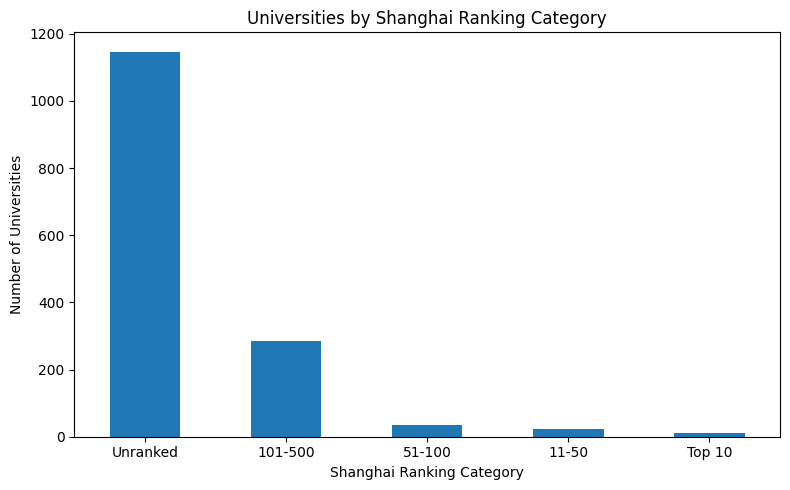

In [26]:
shanghai_category_counts = university_data["shanghai_rank_category"].value_counts()

plt.figure(figsize=(8, 5))
shanghai_category_counts.plot(kind="bar")
plt.xlabel("Shanghai Ranking Category")
plt.ylabel("Number of Universities")
plt.title("Universities by Shanghai Ranking Category")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("chart_4_shanghai_category_bar.png", dpi=120)
plt.show()

## Step 23 — Correlation between QS and Shanghai ranks

                     qs_rank_clean  shanghai_rank_clean
qs_rank_clean             1.000000             0.672655
shanghai_rank_clean       0.672655             1.000000


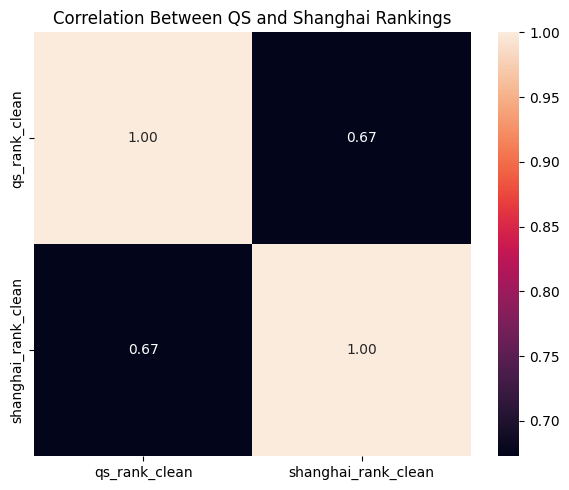

In [27]:
ranking_correlation = university_data[["qs_rank_clean", "shanghai_rank_clean"]].corr()
print(ranking_correlation)

plt.figure(figsize=(6, 5))
sns.heatmap(ranking_correlation, annot=True, fmt=".2f")
plt.title("Correlation Between QS and Shanghai Rankings")
plt.tight_layout()
plt.savefig("chart_5_correlation_heatmap.png", dpi=120)
plt.show()

## Step 24 — Country-wise analysis
Top 10 countries by number of ranked universities in this dataset.

country_territory
United States         192
United Kingdom         90
China                  72
India                  54
Germany                48
Japan                  47
Republic of Korea      43
Italy                  43
Russian Federation     40
Spain                  38
Name: count, dtype: int64


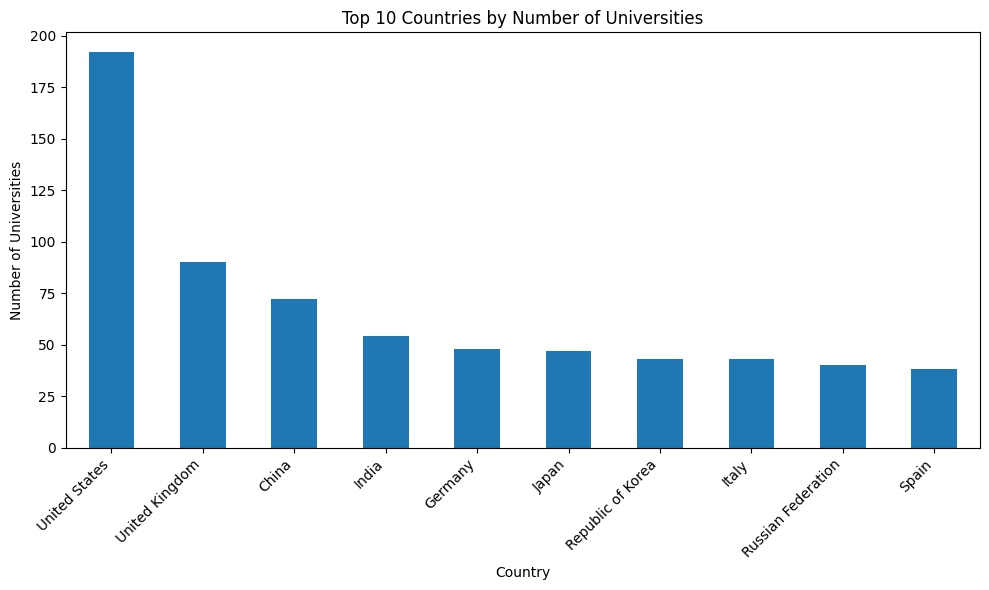

In [28]:
top_countries = university_data[country_col].value_counts().head(10)
print(top_countries)

plt.figure(figsize=(10, 6))
top_countries.plot(kind="bar")
plt.xlabel("Country")
plt.ylabel("Number of Universities")
plt.title("Top 10 Countries by Number of Universities")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("chart_6_top_countries_bar.png", dpi=120)
plt.show()

## Step 25 — Final validation & export the Milestone 2 deliverable


In [29]:
print("========== FINAL VALIDATION ==========")
print("Total Records:", len(university_data))
print("Total Columns:", len(university_data.columns))
print("Duplicate Records:", university_data.duplicated().sum())
print("All 6 KPI columns present:", all(c in university_data.columns for c in kpi_cols))
print("KPI missing values (should all be 0):")
print(university_data[kpi_cols].isnull().sum().to_dict())

university_data.to_excel("university_final_dataset.xlsx", index=False)
print("\nSaved: university_final_dataset.xlsx")
print("Final dataset shape:", university_data.shape)

========== FINAL VALIDATION ==========
Total Records: 1501
Total Columns: 56
Duplicate Records: 0
All 6 KPI columns present: True
KPI missing values (should all be 0):
{'global_ranking_score': 798, 'academic_reputation_score': 0, 'faculty_student_ratio_score': 0, 'international_student_score': 0, 'research_impact_score': 0, 'research_productivity_index': 0}

Saved: university_final_dataset.xlsx
Final dataset shape: (1501, 56)


In [ ]:
"""
University Rankings Dataset Cleaner
------------------------------------
Cleans university_final_dataset_FINAL-1.xlsx:
 1. Removes exact + near-duplicate rows
 2. Standardizes university names
 3. Standardizes country names
 4. Normalizes ranking metrics (0-100 scale, consistent direction)
 5. Exports Tableau-ready CSV files (wide fact table + long-format metrics table)

Usage:
    pip install pandas openpyxl rapidfuzz
    python clean_universities.py

Place this script in the same folder as university_final_dataset_FINAL-1.xlsx
"""

import re
import pandas as pd
import numpy as np
from rapidfuzz import fuzz

INPUT_FILE = r"C:\Users\USER\Downloads\final\university_final_dataset_FINAL (1).xlsx"


df = pd.read_excel(INPUT_FILE, sheet_name="Sheet1")
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
print(f"Loaded {len(df)} rows, {len(df.columns)} columns")


def clean_name(name: str) -> str:
    """Normalize whitespace/punctuation and strip trailing abbreviations
    such as '(MIT)', '(NUS)', 'UCB', etc. that cause near-duplicates."""
    if pd.isna(name):
        return name
    n = str(name).strip()
    n = re.sub(r"\s+", " ", n)                        # collapse whitespace
    n = n.replace("\u2019", "'").replace("`", "'")     # normalize apostrophes
    n = re.sub(r"\s*\(.*?\)\s*", " ", n).strip()       # drop parenthetical abbreviations
    n = re.sub(r"\s+,", ",", n)                        # fix stray spaces before commas
    n = n.rstrip(",").strip()
    return n

df["university_name_clean"] = df["university_name"].apply(clean_name)
df["university_name_key"] = (
    df["university_name_clean"].str.lower()
    .str.replace(r"[^a-z0-9 ]", "", regex=True)
    .str.strip()
)


COUNTRY_MAP = {
    "usa": "United States", "us": "United States", "u.s.a.": "United States",
    "uk": "United Kingdom", "u.k.": "United Kingdom",
    "uae": "United Arab Emirates",
    "korea, south": "South Korea",
    "hong kong": "Hong Kong SAR China",
    "macau": "Macau SAR China", "macao": "Macau SAR China",
    "russian federation": "Russia",
    "czech republic": "Czechia",
}

def clean_country(c: str) -> str:
    if pd.isna(c):
        return c
    c2 = str(c).strip()
    key = c2.lower()
    return COUNTRY_MAP.get(key, c2)

df["country_clean"] = df["country"].apply(clean_country)


before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} exact duplicate rows")


before = len(df)
df = (
    df.sort_values("global_ranking_score", ascending=False)
      .drop_duplicates(subset=["university_name_key", "country_clean"], keep="first")
)
print(f"Removed {before - len(df)} duplicate (name, country) pairs")


def fuzzy_dedupe(frame: pd.DataFrame, threshold: int = 92) -> pd.DataFrame:
    keep_idx = []
    seen_by_country = {}
    for idx, row in frame.iterrows():
        c = row["country_clean"]
        name = row["university_name_key"]
        bucket = seen_by_country.setdefault(c, [])
        is_dup = any(fuzz.ratio(name, existing) >= threshold for existing in bucket)
        if not is_dup:
            bucket.append(name)
            keep_idx.append(idx)
    return frame.loc[keep_idx]

before = len(df)
df = fuzzy_dedupe(df)
print(f"Removed {before - len(df)} fuzzy near-duplicate rows")


score_cols = [c for c in df.columns if c.endswith("_score") or c.endswith("_index")]
for col in score_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").clip(0, 100)


for rank_col, out_col in [("qs_rank", "qs_rank_norm"), ("arwu_rank", "arwu_rank_norm")]:
    r = pd.to_numeric(df[rank_col], errors="coerce")
    max_r = r.max()
    df[out_col] = np.where(r.notna(), 100 * (1 - (r - 1) / (max_r - 1)), np.nan)
    df[out_col] = df[out_col].round(2)


for col in ["qs_rank_category", "arwu_rank_category"]:
    df[col] = df[col].fillna("Unranked").astype(str).str.strip().str.title()

df["ranking_comparison"] = df["ranking_comparison"].fillna("Not Comparable").astype(str).str.strip()


df = df.rename(columns={"university_name_clean": "university_name_final",
                         "country_clean": "country_final"})

final_cols = [
    "university_name_final", "country_final", "region", "university_size", "focus",
    "research_intensity", "institution_status",
    "global_ranking_score", "qs_published_overall_score",
    "qs_rank", "qs_rank_category", "qs_rank_norm",
    "arwu_rank", "arwu_rank_category", "arwu_rank_norm",
    "rank_difference", "absolute_rank_difference", "ranking_comparison",
    "academic_reputation_score", "employer_reputation_score",
    "faculty_student_ratio_score", "international_student_score",
    "international_faculty_score", "international_student_diversity_score",
    "international_research_network_score", "research_impact_score",
    "research_productivity_index", "employment_outcomes_score",
    "sustainability_score",
    "arwu_overall_score", "arwu_alumni_score", "arwu_award_score",
    "arwu_highly_cited_researchers_score", "arwu_nature_science_score",
    "arwu_publications_score", "arwu_per_capita_score",
]
final_cols = [c for c in final_cols if c in df.columns]
clean_df = df[final_cols].rename(columns={
    "university_name_final": "university_name",
    "country_final": "country",
})

clean_df.insert(0, "university_id", range(1, len(clean_df) + 1))



clean_df.to_csv("universities_clean_wide.csv", index=False)


metric_cols = [c for c in clean_df.columns if c.endswith("_score") or c.endswith("_norm")
               or c.endswith("_index") or c in ("qs_rank", "arwu_rank")]
long_df = clean_df.melt(
    id_vars=["university_id", "university_name", "country", "region"],
    value_vars=metric_cols,
    var_name="metric_name",
    value_name="metric_value",
)
long_df.to_csv("universities_clean_long.csv", index=False)

print(f"\nFinal clean dataset: {len(clean_df)} unique universities")
print("Exported: universities_clean_wide.csv, universities_clean_long.csv")
